## This is a simple waterfall code I used. Not all the filterbank files that this notebook runs is not directly available via zenodo due to file sizes

In [1]:
import numpy as np
import pandas as pd
import your
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import matplotlib as mpl
from matplotlib import colors
from scipy.optimize import curve_fit, leastsq
import numpy.ma as ma
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator

from typing import Union, List

import frb_functions

In [2]:
frb_functions.get_subband_edges(bandwidth=256, n_chan=512)

bandwidth is: 256 . Number of channels: 512 . First subband array:  [ 0 63]
Subband edges:  64


array([  0,  63,  64, 127, 128, 191, 192, 255, 256, 319, 320, 383, 384,
       447, 448, 511])

In [3]:
def gaus(x,a,x0,sigma,d):
    return a*np.exp(-(x-x0)**2/(2*sigma**2))+d

In [4]:
def waterfaller_maker(burst, DM, offset_sec, id, window=5, downsamp_t=1, downsamp_f=1, \
                      plot_spectrum=False, save_bool=False, wind_spectrum=None, dededisp=None):
    
    #Define the figure
    fig5 = plt.figure(figsize=(10,10))

    rows = 2
    cols = 1    
    if plot_spectrum: cols += 1
    widths = [1]
    heights = [1, 1.5]
    spec5 = fig5.add_gridspec(ncols=cols, nrows=rows, \
                          height_ratios=[0.6, 1.4], \
                          width_ratios=[5,]+[1,]*(cols-1), \
                          wspace=0.0, hspace=0.0)
    # spec5 = fig5.add_gridspec(ncols=cols, nrows=rows, \
    #                           height_ratios=[1,]*(rows-1)+[2,], width_ratios=[5,]+[1,]*(cols-1),
    #                           #width_ratios=widths, height_ratios=heights,\
    #                           wspace=0.0, hspace=0.0)

    # #Gridspec in Gridspec
    # rows = 2
    # cols = 1
    # if plot_spectrum: cols += 1
    # plot_grid = gridspec.GridSpecFromSubplotSpec(rows, cols, plot_grid_idx, wspace=0., hspace=0.,
    #                                              height_ratios=[1,]*(rows-1)+[2,], width_ratios=[5,]+[1,]*(cols-1))
    
    # ax1 = plt.Subplot(fig, plot_grid[rows-1,0])
    # ax2 = plt.Subplot(fig, plot_grid[rows-2,0], sharex=ax1)
    #ax1 = fig5.add_subplot(spec5[0, 0], sharex=ax2)
    

    ###################################
    #Loading in the burst
    burst = your.Your(burst)

    #Getting the info of the headerfile
    header_dict = frb_functions.your_header_to_dict(burst)
    tsamp = header_dict["tsamp"]
    nbins = header_dict["nspectra"]
    fsamp = header_dict["foff"] * -1
    freqs = header_dict["freqs"] # in Mhz
    
    #Extracting the extent
    tmin = 0.0
    tmax = nbins * burst.tsamp # seconds
    fmin = header_dict["fmin"]
    fmax = header_dict["fmax"]
    extent_b = [tmin, tmax, fmin, fmax]

    #Aligning the burst in the middle
    offset = offset_sec
    extent_b[0] = (tmin - offset) * 1000
    extent_b[1] = (tmax - offset) * 1000
    print(f"the extent of the data is: {extent_b}")
    
    #time increasing, freq decreasing
    #Loading in the data, pol1 (StokesI)
    print("loading in the data")
    d = frb_functions.get_data(burst,nstart=0, nsamp=nbins, npoln=1)

    #De-dispersing in case you want to change the DM from the original
    if dededisp != None:
        print(f"de-de-dispersing to DM zero using {dededisp} pc/cc")
        d = frb_functions.dedisperse(d,dededisp,freqs,tsamp)

    #Dedispersing the data
    dm_dedisp = DM
    print(f"de-dispersing to {dm_dedisp} pc/cc")
    stokes_i = frb_functions.dedisperse(d,dm_dedisp,freqs,tsamp)

    #Correcting the bandpass
    print(f"Correcting for the bandpass")
    stokes_i_norm = frb_functions.correct_bandpass(stokes_i, scale=3, sides="right")

    #In case of downsampling
    print(f"downsample factors are: time:{downsamp_t} and freq:{downsamp_f}")
    if downsamp_f > 1 or downsamp_t > 1:
        print(f"running downsampling and correcting bandpass")
        stokes_i_norm = frb_functions.downsample(stokes_i_norm, freqf=downsamp_f, timef=downsamp_t)
        tsamp = tsamp * downsamp_t
        fsamp = fsamp * downsamp_f
        stokes_i_norm = frb_functions.correct_bandpass(stokes_i_norm, scale=3, sides="right")
        downsamp_flag = True

        #Very specific for p47028_o8
        #bad_chans_1 = np.arange(0,512/downsamp_f,dtype=int)
        #bad_chans_2 = np.arange(4064/downsamp_f,4095/downsamp_f,dtype=int)
        #bad_chans = np.concatenate((bad_chans_1, bad_chans_2), axis=None)
        #print(f"Masking bad channels")
        #stokes_i_norm = frb_functions.correct_bandpass(stokes_i_norm, scale=3, sides="right")
        #stokes_i_norm = frb_functions.mask_array(stokes_i_norm, bad_chans)
        
    else:
        downsamp_flag = False

    #Masking Subband edges
    print(f"Masking subband edges")
    nchans = header_dict["nchans"]
    bw = header_dict["bw"] * -1
    print(f"channel numbers: {nchans}")
    nchans_n = nchans/downsamp_f
    subband_edges_arr = frb_functions.get_subband_edges(bandwidth=bw, n_chan=int(nchans/downsamp_f))
    stokes_i_norm = frb_functions.mask_array(stokes_i_norm, subband_edges_arr)     

    # bad_chans = np.arange(0,512,dtype=int)
    # stokes_i_norm = frb_functions.mask_array(stokes_i_norm, bad_chans) 
    
    new_quantiles = np.nanpercentile(stokes_i_norm.compressed(), (1.0, 99.99))

    #Without masking use this expression
    #new_quantiles = np.percentile(stokes_i, (1.0, 99.9))
    
    #Setting up the dynamic spectra [ax2]
    ax2 = fig5.add_subplot(spec5[1, 0]) 
    ax2.imshow(stokes_i_norm, aspect='auto', interpolation='None',\
          extent=extent_b, vmin=new_quantiles[0], vmax=new_quantiles[1])
    window_ms = window
    ax2.set_xlim(-window_ms,window_ms)
    ax2.set_ylabel('Frequency (MHz)',size=25)
    ax2.set_xlabel('Time (ms)',size=25)
    ax2.yaxis.set_major_locator(ticker.LinearLocator(5))
    ax2.xaxis.set_minor_locator(ticker.MultipleLocator(10))

    #Create x grid to plot the step function of the time series
    x_grid = np.linspace(extent_b[0], extent_b[1], endpoint=False, num=stokes_i_norm.shape[1])
    prof = np.mean(stokes_i_norm,axis=0)
    stokes_i_normprof = frb_functions.normalize_1d(prof,sides="right", scale=3)
    
    ax1 = fig5.add_subplot(spec5[0, 0], sharex=ax2)
    ax1.set_ylabel('S/N',size=25)
    ax1.plot(x_grid, stokes_i_normprof, drawstyle='steps-post', color='black')
    
    #Ticks on the SN-
    maxSN = np.ceil(np.max(stokes_i_normprof))
    yticks_sn=np.array([0,int(maxSN/2),int(maxSN)+2])
    ax1.set_yticks(yticks_sn)
    
    if plot_spectrum: 
        ax3 = fig5.add_subplot(spec5[1, 1], sharey=ax2) #Drawing

        #We know the time of the burst, since it's stored in offset (in sec)

        burst_bin = offset / tsamp #The bin where the offset is defined
        spectrum_window_ms = wind_spectrum #How large the window should be by eye in ms
        spectrum_window_bins = int(spectrum_window_ms / (tsamp*1e3))

        spectrum_beg = burst_bin-(spectrum_window_bins/2)
        spectrum_end = burst_bin+(spectrum_window_bins/2)
        spectrum_arr_slice = stokes_i_norm[:, int(spectrum_beg):int(spectrum_end)]
        spectrum = np.mean(spectrum_arr_slice, axis=-1)

        y = np.linspace(extent_b[2], extent_b[3], spectrum.size)
        ax3.plot(spectrum, y,'k-',zorder=2, lw=0.7,drawstyle='steps-post')
        ax3.tick_params(labelleft=False, labelbottom=False, labeltop=False, labelright=False, bottom=False, top=False, left=False, right=False)
        ax3.tick_params(which="both", direction='in')
        ax3.set_ylim(extent_b[2],extent_b[3])
        x_range = spectrum.max() - spectrum.min()

        y_range = stokes_i_normprof.max() - stokes_i_normprof.min()

        #ax1.hlines(y=-y_range/4,xmin=-spectrum_window_ms/2,xmax=spectrum_window_ms/2, lw=10, color='orange', alpha=0.4) 
        print(y_range)

    #ax1.set_ylim(-10,maxSN+10)
    
    ax1.text(0.96, 0.93, f"{id}", transform=ax1.transAxes, fontsize=22, va='top', ha='right')
    ax1.text(0.04, 0.93, fr"$\Delta$t  = {(tsamp*1e6):.0f} $\mu$s" + "\n" + fr"$\Delta \nu$  = {(fsamp*1e3):.0f} kHz " + "\n" + \
             fr"DM = {DM:.2f}"+ r" pc cm$^{-3}$", transform=ax1.transAxes, fontsize=19, va='top', ha='left')
    
    ###################################
    #Setting labels and ticks 
    if plot_spectrum:
        axes = [ax1,ax2,ax3]
    else:
        axes = [ax1,ax2]
        
    for ax in axes:
        
        ax.tick_params(labelsize=22) 
        
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2)

            ax.tick_params(axis='y', which='major', direction='out', length=10, width=2)
            ax.tick_params(axis='y', which='minor', direction='out', length=5, width=2)
            ax.tick_params(axis='x', which='major', direction='out', length=10, width=2)
            ax.tick_params(axis='x', which='minor', direction='out', length=5, width=2)
    
    for ax in [ax1]:
        
        ax.tick_params(labelbottom=False)
        ax.tick_params(axis='x', which='major', direction='in', length=10, width=2)
        ax.tick_params(axis='x', which='minor', direction='in', length=5, width=2)

    
    #plot_name = header_dict["basename"] + f"_{(2*window_ms)}ms"
    if save_bool == True:
        plot_name = f"{id}-" + header_dict["basename"] + f"_{(2*window_ms)}ms" + f"_{(tsamp*1e6):.0f}us_" + f"{(fsamp*1e3):.0f}kHz"
        print(f"plot_name: {plot_name}")
        fig5.savefig(plot_name + ".pdf", dpi=300, bbox_inches='tight')
        fig5.savefig(plot_name + ".png", facecolor='white', \
                transparent=False, format = 'png',bbox_inches='tight', dpi=300)
    
    return



the extent of the data is: [-1160.0, 1656.0, 1380.0, 1508.0]
loading in the data
de-de-dispersing to DM zero using -527.7 pc/cc
de-dispersing to 528.75 pc/cc
Correcting for the bandpass
downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 1024
bandwidth is: 128.0 . Number of channels: 1024 . First subband array:  [  0   1 126 127]
Subband edges:  128


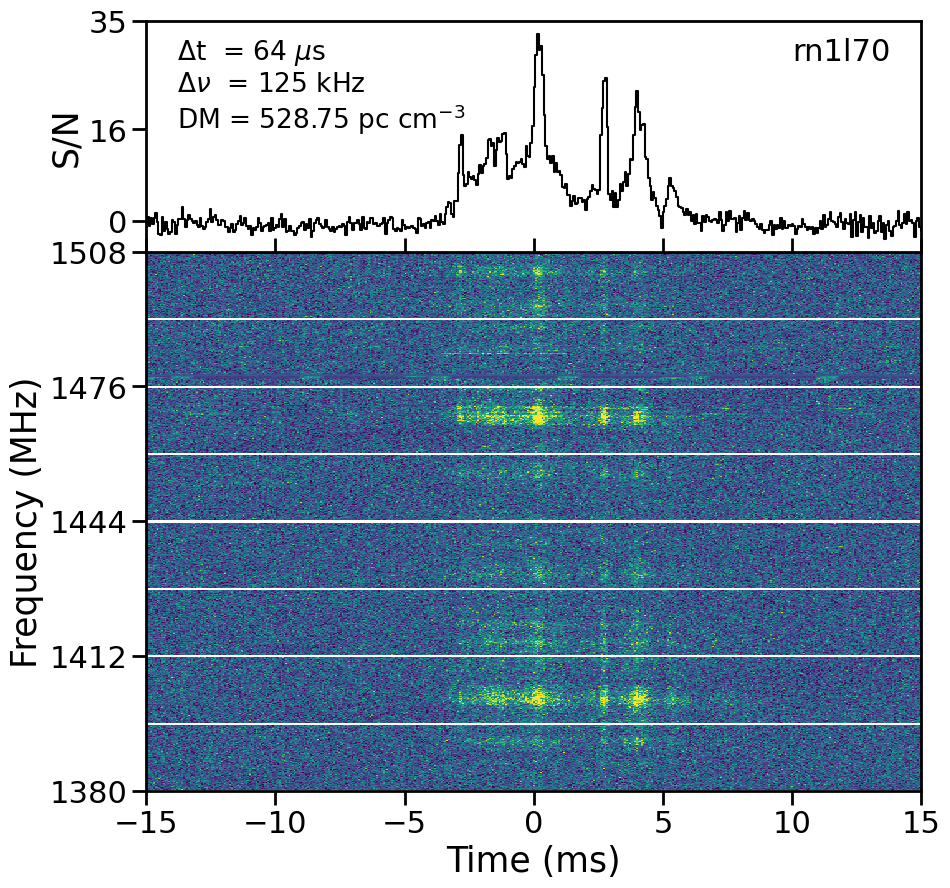

In [8]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/rn1l70_7_tr_60698.53843/rn1l70_7_64us_125KHz_StokesI_DM5277.cor_Tr.fil", \
                  DM=528.75, offset_sec=1.16, window=15, downsamp_t=1, downsamp_f=1,\
                  id="rn1l70", dededisp=-527.7, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1082.0, 1733.9999999999998, 1207.0, 1335.0]
loading in the data
de-de-dispersing to DM zero using -528.4 pc/cc
de-dispersing to 528.4 pc/cc
Correcting for the bandpass
downsample factors are: time:256 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


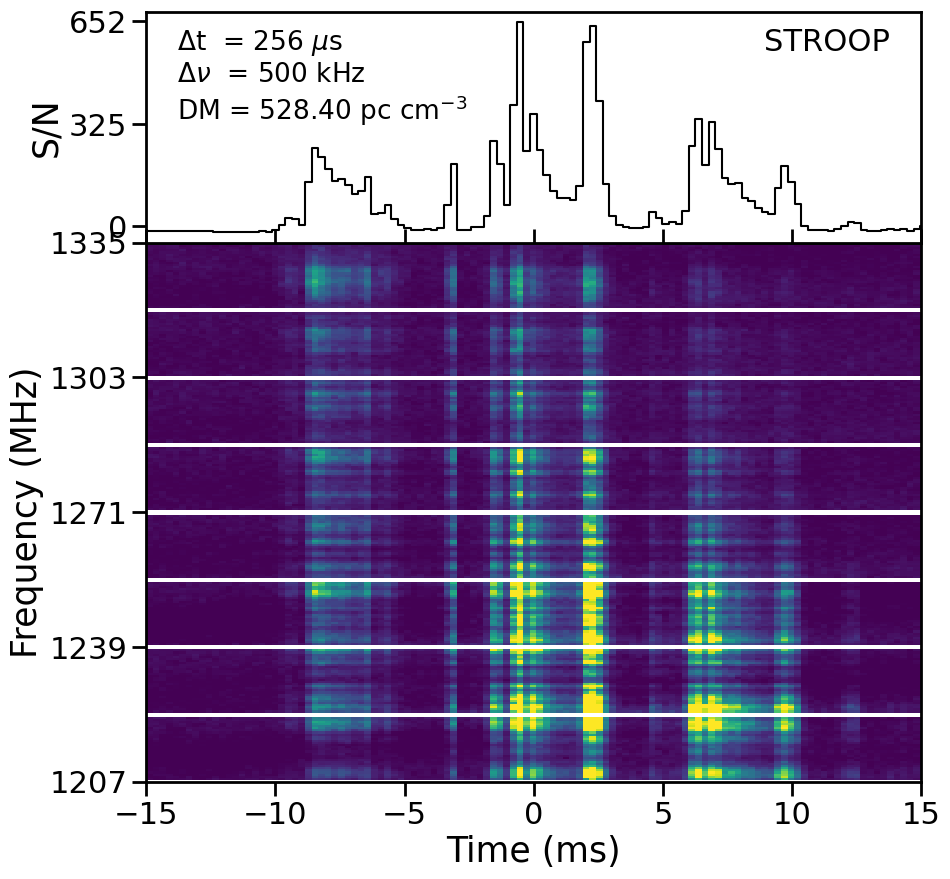

In [13]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p55097_41_wb_60586.95300/p55097_41_1us_500KHz_StokesI_DM5284.cor_Wb.fil", \
                  DM=528.4, offset_sec=1.082, window=15, downsamp_t=256, downsamp_f=1,\
                  id="STROOP", dededisp=-528.4, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-2012.0, 6180.0, 300.0, 356.0]
loading in the data
de-de-dispersing to DM zero using -527.854 pc/cc
de-dispersing to 527.854 pc/cc
Correcting for the bandpass
downsample factors are: time:1 and freq:2
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 448
bandwidth is: 56.0 . Number of channels: 224 . First subband array:  [ 0 27]
Subband edges:  28


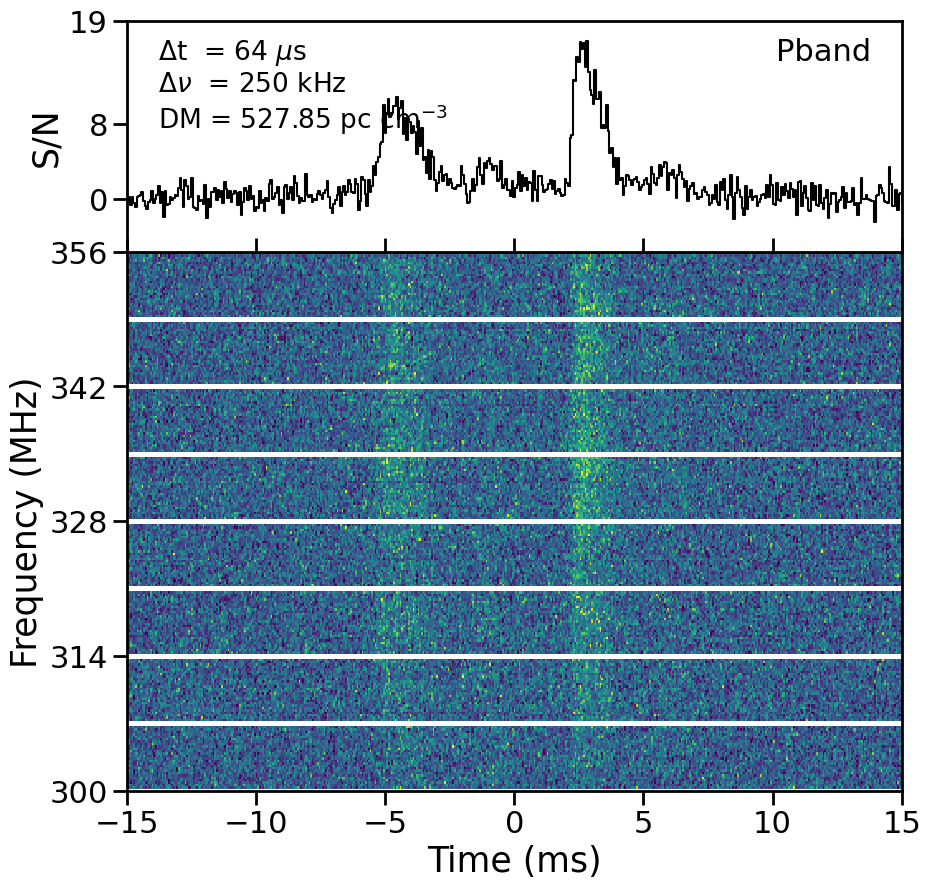

In [37]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p47030_21_wb_60386.37678/p47030_21_64us_125KHz_StokesI_DM527854.cor_Wb.fil", \
                  DM=527.854, offset_sec=2.012, window=15, downsamp_t=1, downsamp_f=2,\
                  id="Pband", dededisp=-527.854, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1666.0, 1150.0, 1380.0, 1508.0]
loading in the data
de-de-dispersing to DM zero using -527.7 pc/cc
de-dispersing to 527.854 pc/cc
Correcting for the bandpass


/home/omar/git/mimir/scripts/frb_functions.py:300: RuntimeWarning: invalid value encountered in divide
  data_bpc = (data - bp_mean[:, None]) / bp_std[:, None]


downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 1024
bandwidth is: 128.0 . Number of channels: 1024 . First subband array:  [  0   1 126 127]
Subband edges:  128


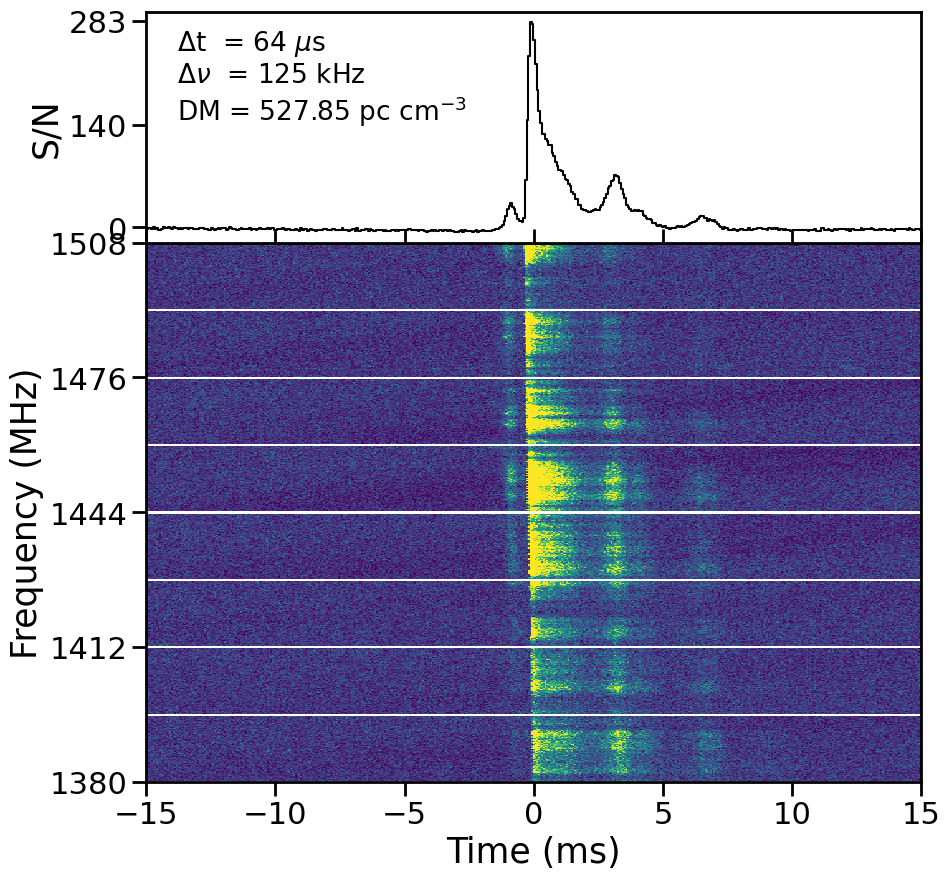

In [11]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/rn1l62_14_tr_60674.67263/rn1l62_14_64us_125KHz_StokesI_DM5277.cor_Tr.fil", \
                  DM=527.854, offset_sec=1.666, window=15, downsamp_t=1, downsamp_f=1,\
                  id="", dededisp=-527.70, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-2009.9999999999998, 6182.0, 300.0, 356.0]
loading in the data
de-de-dispersing to DM zero using -527.7 pc/cc
de-dispersing to 527.854 pc/cc
Correcting for the bandpass
downsample factors are: time:4 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 112
bandwidth is: 56.0 . Number of channels: 112 . First subband array:  [ 0 13]
Subband edges:  14


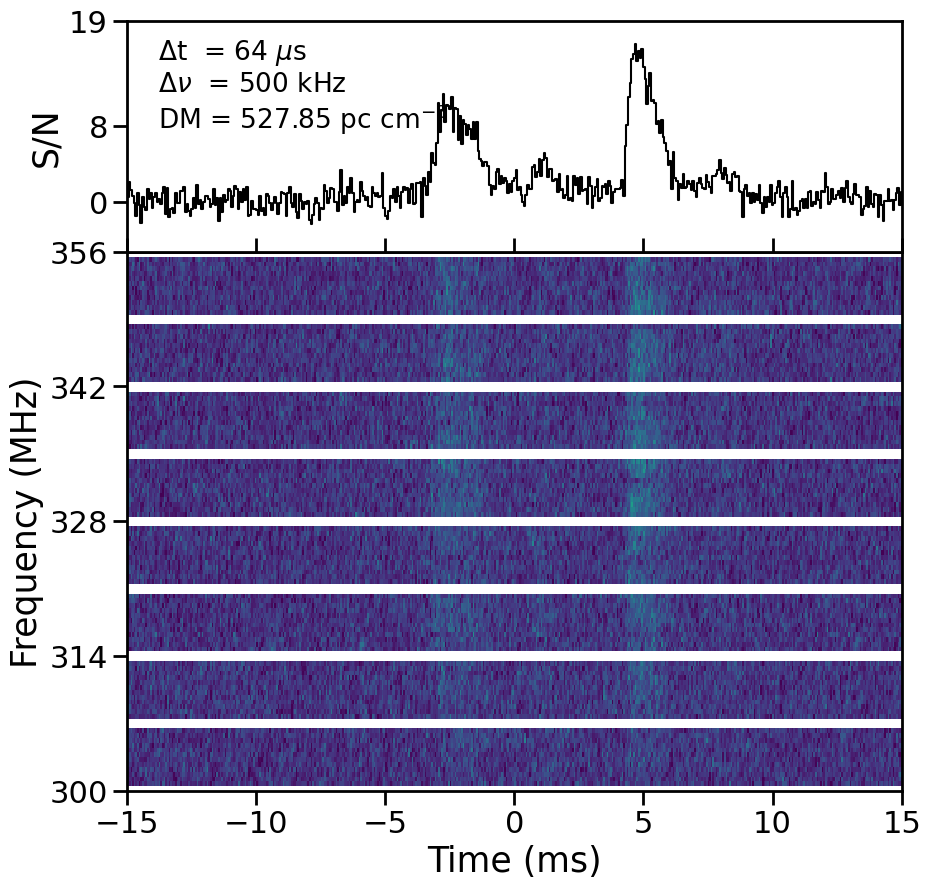

In [7]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p47030_21_wb_60386.37678/p47030_21_16us_500KHz_StokesI_DM5277.cor_Wb.fil", \
                  DM=527.854, offset_sec=2.01, window=15, downsamp_t=4, downsamp_f=1,\
                  id="", dededisp=-527.70, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1982.0, 833.9999999999999, 1360.0, 1488.0]
loading in the data
de-de-dispersing to DM zero using -527.7 pc/cc
de-dispersing to 528.2 pc/cc
Correcting for the bandpass
downsample factors are: time:2 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 1024
bandwidth is: 128.0 . Number of channels: 1024 . First subband array:  [  0   1 126 127]
Subband edges:  128


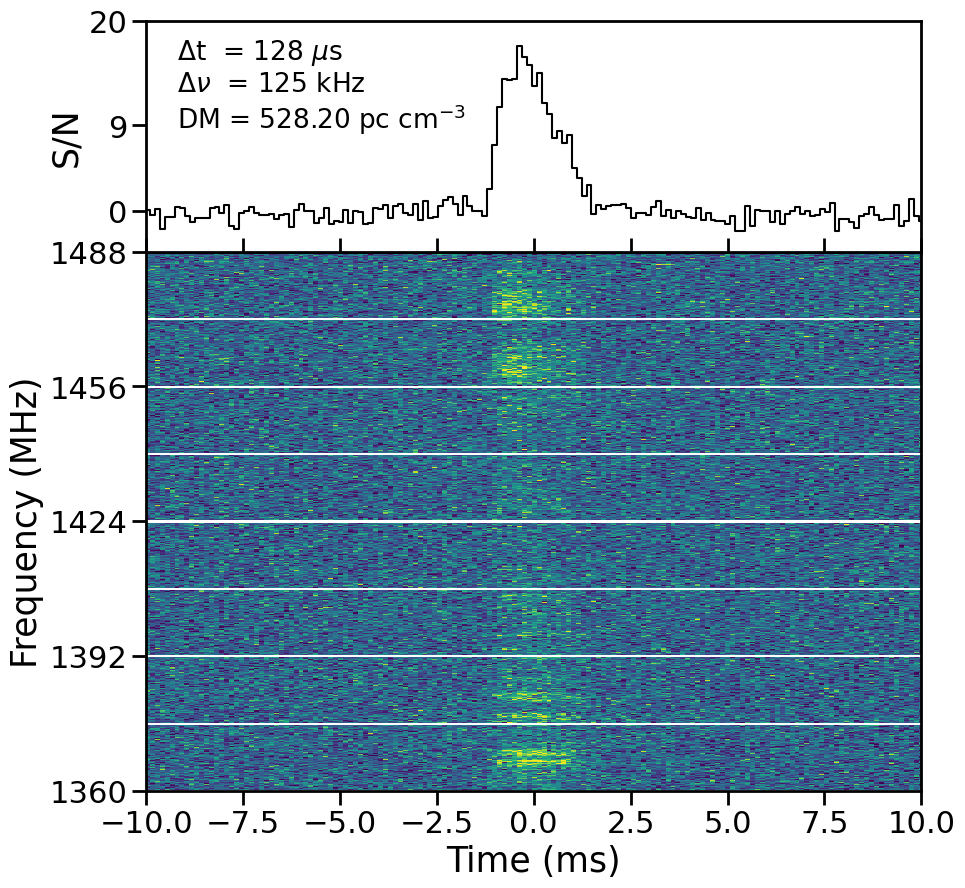

In [27]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p47028_24_o8_60384.41118/p47028_24_64us_125KHz_StokesI_DM5277.cor_O8.fil", \
                  DM=528.2, offset_sec=1.982, window=10, downsamp_t=2, downsamp_f=1,\
                  id="", dededisp=-527.70, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1548.2, 1267.7999999999997, 1360.0, 1488.0]
loading in the data
de-de-dispersing to DM zero using -527.7 pc/cc
de-dispersing to 527.85 pc/cc
Correcting for the bandpass
downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 1024
bandwidth is: 128.0 . Number of channels: 1024 . First subband array:  [  0   1 126 127]
Subband edges:  128


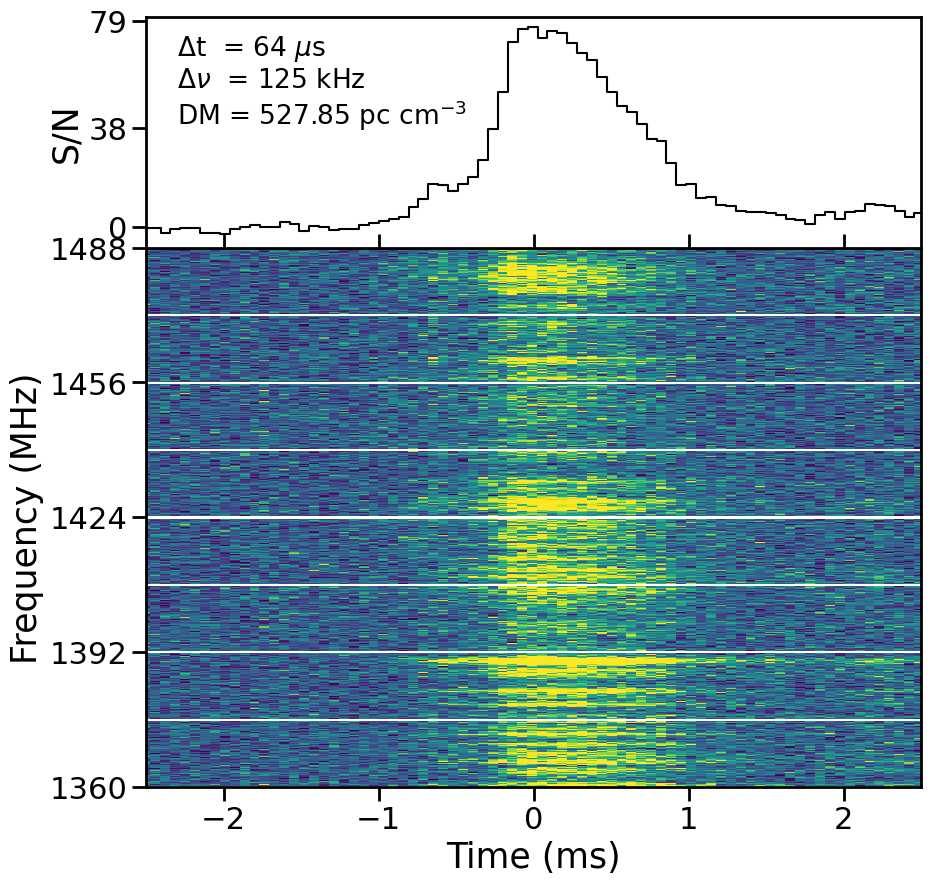

In [47]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p47027_10_o8_60383.26844/p47027_10_64us_125KHz_StokesI_DM5277.cor_O8.fil", \
                  DM=527.85, offset_sec=1.5482, window=2.5, downsamp_t=1, downsamp_f=1,\
                  id="", dededisp=-527.70, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1740.0, 1075.9999999999998, 1360.0, 1488.0]
loading in the data
de-de-dispersing to DM zero using -527.7 pc/cc
de-dispersing to 528.0 pc/cc
Correcting for the bandpass
downsample factors are: time:4 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


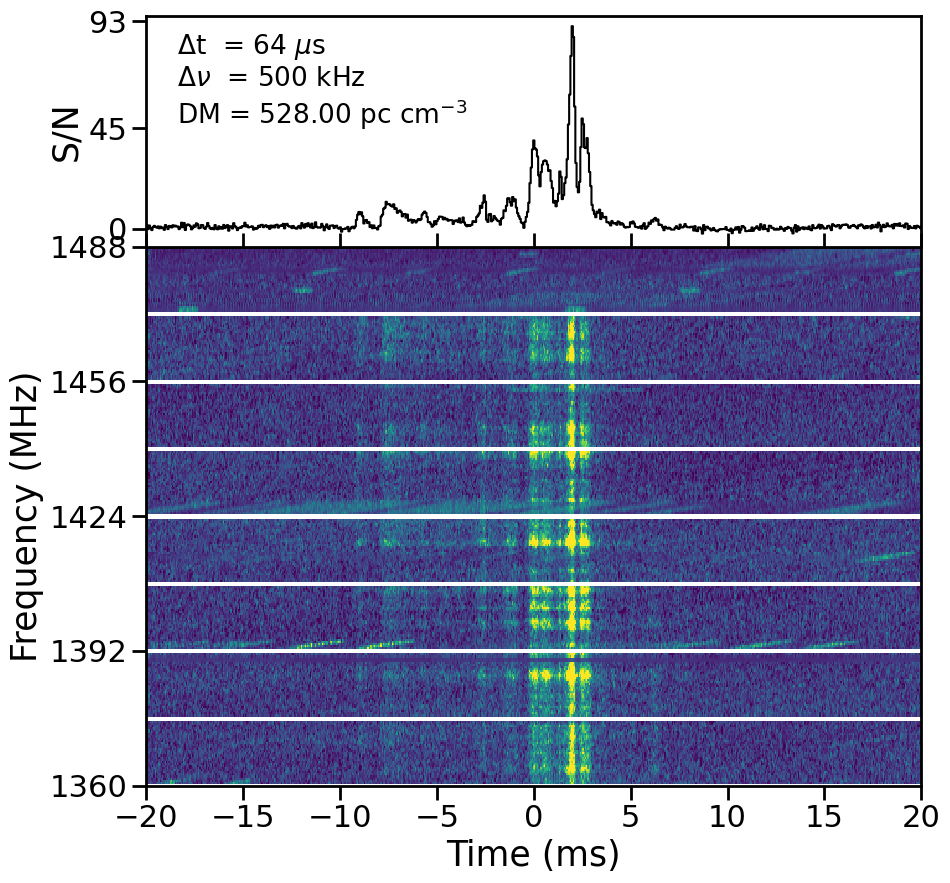

In [10]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p47064_38_o8_60431.43777/p47064_38_16us_500KHz_StokesI_DM5277.cor_O8.fil", \
                  DM=528.0, offset_sec=1.740, window=20, downsamp_t=4, downsamp_f=1,\
                  id="", dededisp=-527.70, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1929.0, 886.9999999999998, 1360.0, 1488.0]
loading in the data
de-de-dispersing to DM zero using -527.831 pc/cc
de-dispersing to 527.831 pc/cc
Correcting for the bandpass
downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 1024
bandwidth is: 128.0 . Number of channels: 1024 . First subband array:  [  0   1 126 127]
Subband edges:  128


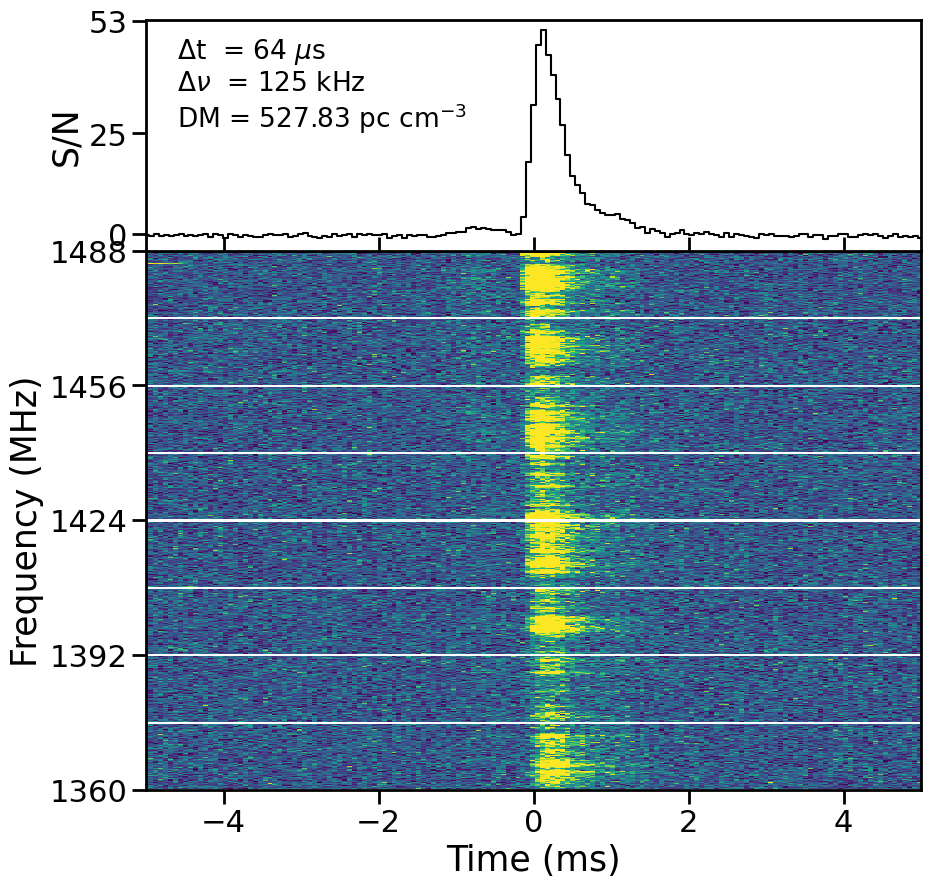

In [24]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p47024_24_o8_60380.45214/p47024_24_64us_125KHz_StokesI_DM5277.cor_O8.fil", \
                  DM=527.831, offset_sec=1.929, window=5.0, downsamp_t=1, downsamp_f=1,\
                  id="", dededisp=-527.831, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-807.0, 2009.0, 1380.0, 1508.0]
loading in the data
de-de-dispersing to DM zero using -528.47 pc/cc
de-dispersing to 528.47 pc/cc
Correcting for the bandpass
downsample factors are: time:16 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


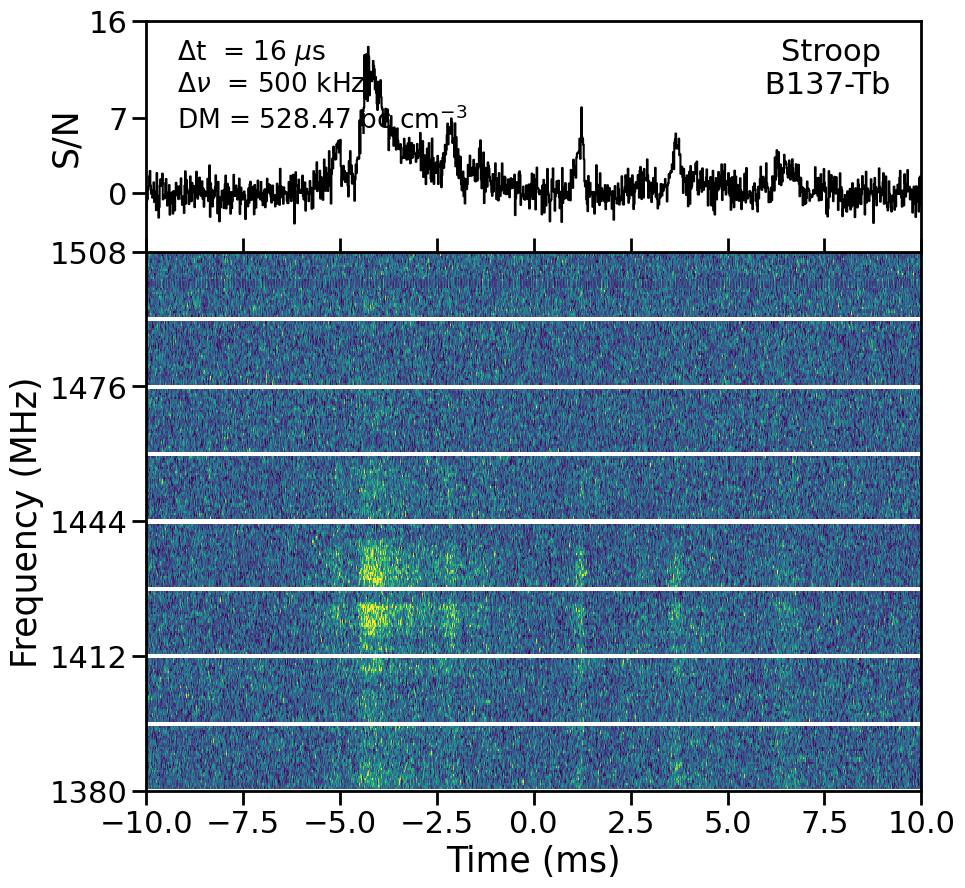

In [5]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/rn1l40_17_tr_60586.95300/rn1l40_17_1us_500KHz_StokesI_DM52847.cor_Tr.fil", \
                  DM=528.47, offset_sec=0.807, window=10, downsamp_t=16, downsamp_f=1,\
                  id="Stroop \n B137-Tb", dededisp=-528.47, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1078.848, 713.1519999999998, 1207.0, 1335.0]
loading in the data
de-de-dispersing to DM zero using -528.47 pc/cc
de-dispersing to 528.47 pc/cc
Correcting for the bandpass
downsample factors are: time:4 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


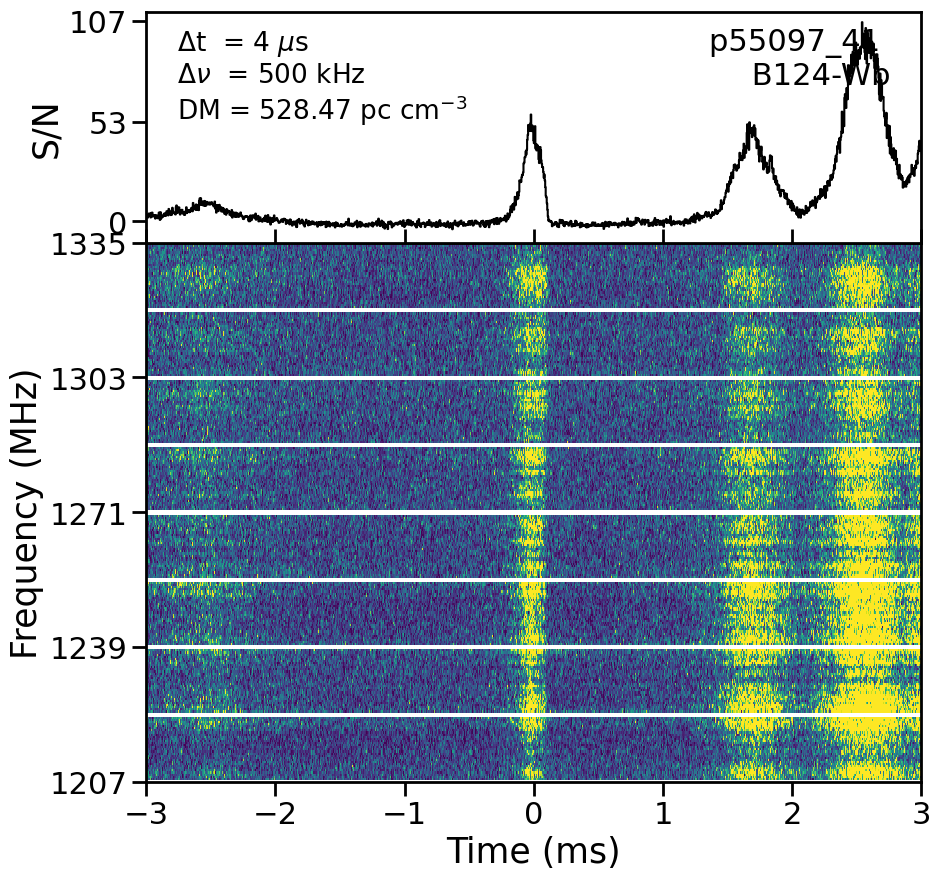

In [12]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p55097_41/p55097_41_1us_500KHz_StokesI_DM52847.cor_Wb.fil", \
                  DM=528.47, offset_sec=1.078848, window=3, downsamp_t=4, downsamp_f=1,\
                  id="p55097_41 \n B124-Wb", dededisp=-528.47, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1078.848, 713.1519999999998, 1207.0, 1335.0]
loading in the data
de-de-dispersing to DM zero using -528.47 pc/cc
de-dispersing to 528.47 pc/cc
Correcting for the bandpass
downsample factors are: time:8 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


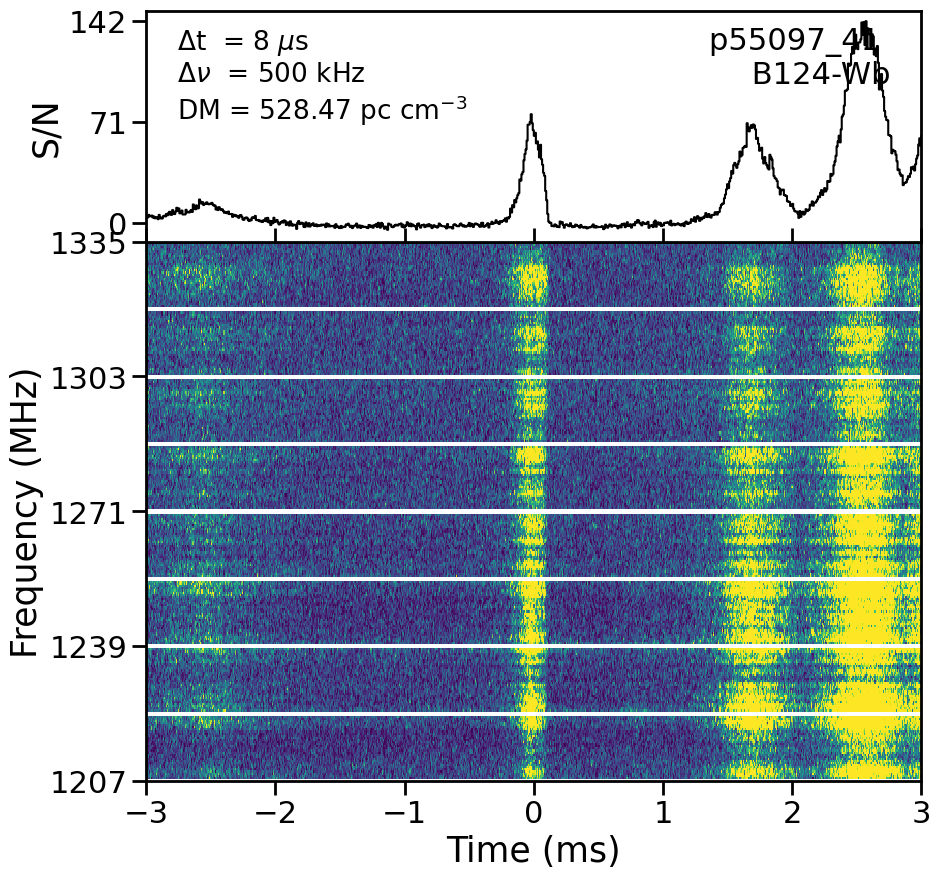

In [13]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p55097_41/p55097_41_1us_500KHz_StokesI_DM52847.cor_Wb.fil", \
                  DM=528.47, offset_sec=1.078848, window=3, downsamp_t=8, downsamp_f=1,\
                  id="p55097_41 \n B124-Wb", dededisp=-528.47, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1083.0, 708.9999999999999, 1207.0, 1335.0]
loading in the data
de-de-dispersing to DM zero using -528.47 pc/cc
de-dispersing to 528.47 pc/cc
Correcting for the bandpass
downsample factors are: time:1 and freq:1
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


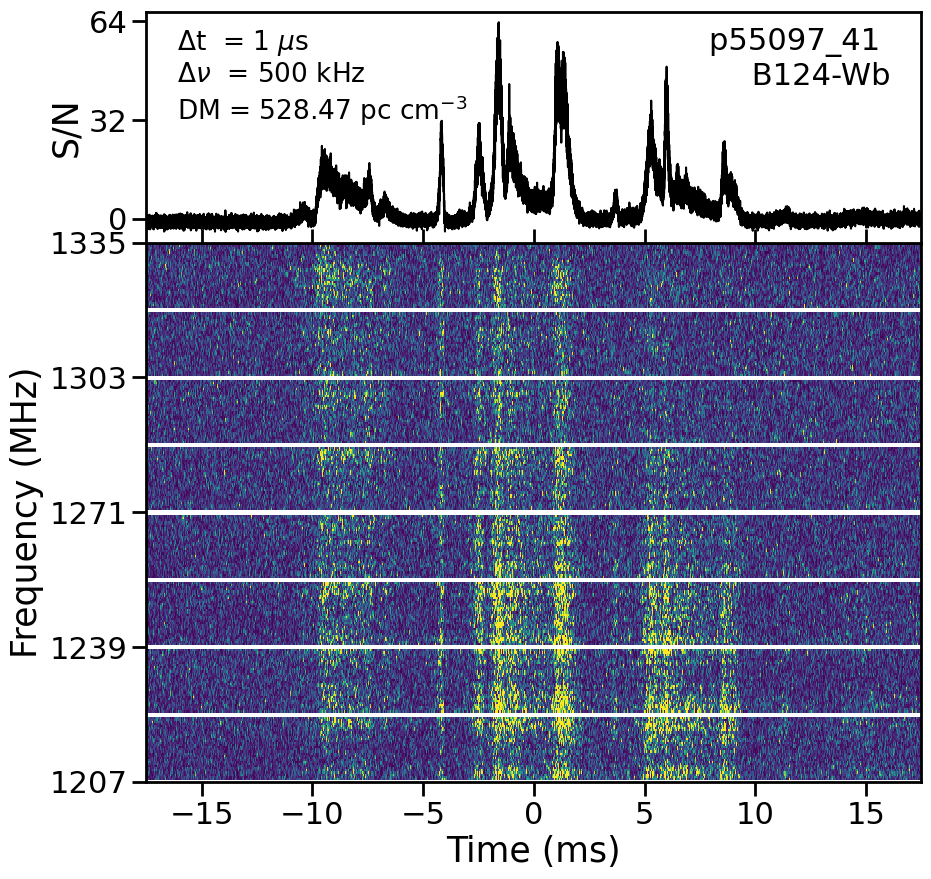

In [14]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p55097_41/p55097_41_1us_500KHz_StokesI_DM52847.cor_Wb.fil", \
                  DM=528.47, offset_sec=1.083, window=17.5, downsamp_t=1, downsamp_f=1,\
                  id="p55097_41 \n B124-Wb", dededisp=-528.47, plot_spectrum=False, wind_spectrum=None, save_bool=False)

the extent of the data is: [-1083.0, 708.9999999999999, 1207.0, 1335.0]
loading in the data
de-de-dispersing to DM zero using -528.47 pc/cc
de-dispersing to 528.47 pc/cc
Correcting for the bandpass
downsample factors are: time:8 and freq:1
running downsampling and correcting bandpass
Masking subband edges
channel numbers: 256
bandwidth is: 128.0 . Number of channels: 256 . First subband array:  [ 0 31]
Subband edges:  32


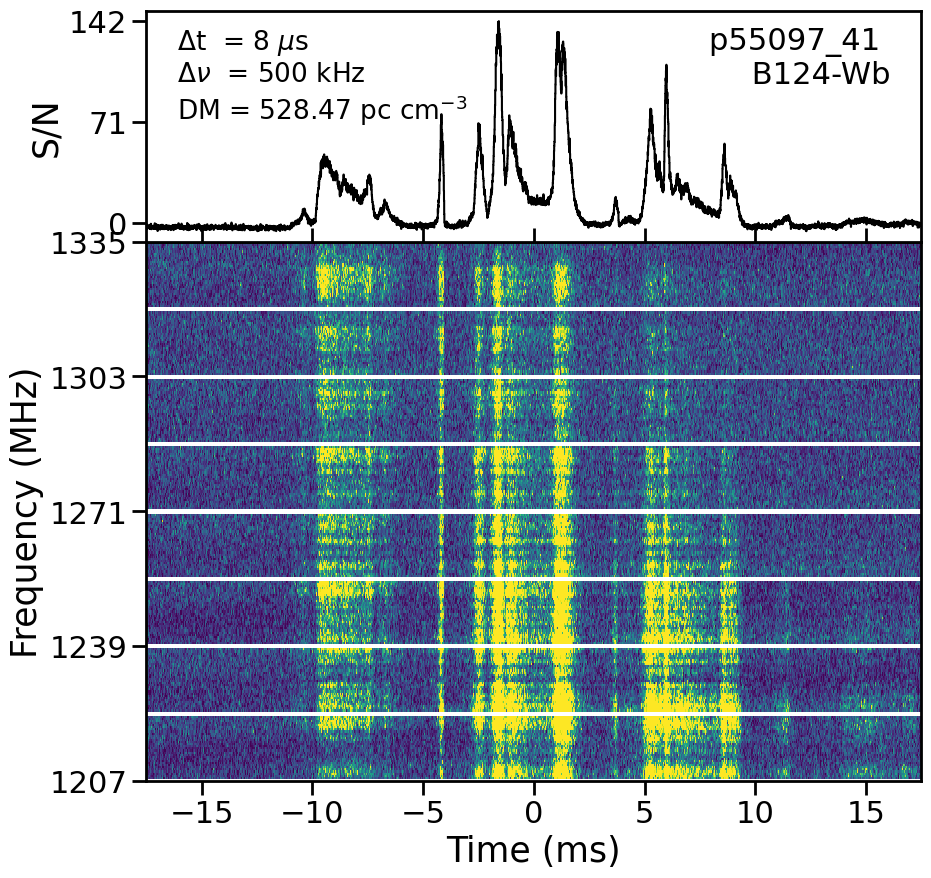

In [15]:
waterfaller_maker(burst="/data1/omar/sfxc/frb240114a/p55097_41/p55097_41_1us_500KHz_StokesI_DM52847.cor_Wb.fil", \
                  DM=528.47, offset_sec=1.083, window=17.5, downsamp_t=8, downsamp_f=1,\
                  id="p55097_41 \n B124-Wb", dededisp=-528.47, plot_spectrum=False, wind_spectrum=None, save_bool=False)